In [11]:
import numpy as np
from sklearn.decomposition import PCA

In [10]:
filename = 'COMPILE.csv'
dense_coding_table = []
for line in open(filename):
    dense_coding_table.append(line.strip('\n').split(','))
for x in dense_coding_table[:10]:
    print(x)

['verse', 'eng', 'cym', 'deu', 'fin', 'hat', 'hau', 'hin', 'jav', 'pol', 'tur', 'yor']
['40012040', 'in', 'yn', 'in', '-ssa', 'nan', 'cikin', 'mẽ', 'ing', 'w', '-inda', 'ninu']
['40024040', 'in', 'yn', 'auf', '-lla', 'nan', 'a', 'mẽ', 'ing', 'na', '-da', 'li']
['40026006', 'in', 'yn', 'in', '-ssa', '--', 'a', 'mẽ', 'ing', 'w', '-da', 'ni']
['40027038', 'on', 'ar', 'zur', '-lle', 'sou', 'a', 'par', 'ing', 'z', '-inda', 'li']
['41001004', 'in', 'yn', 'in', '-ssa', 'nan', 'a', 'mẽ', 'ing', 'na', '-da', 'ni']
['41001019', 'in', 'yn', 'in', '-ssa', 'nan', 'cikin', 'par', 'ing', 'w', '-da', 'ninu']
['41006047', 'on', 'ar', 'auf', '--', '--', 'a', 'par', 'ing', 'na', '-da', 'ni']
['41009033', 'in', 'NULL', 'in', '--', '--', '--', '--', 'ing', 'w', '--', 'ninu']
['41013008', 'in', 'mewn', '--', '-lla', 'NULL', 'a', '--', 'ing', 'w', '--', 'ni']


In [24]:
def get_sparse_coding(dense_coding_table, no_response):
    languages = dense_coding_table[0][1:]
    sparse_dict = { language : {} for language in languages }
    sparse_coding_table = []
    for i,language in enumerate(languages, start=1):
        for row in dense_coding_table[1:]:
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                elif morpheme not in sparse_dict[language]: 
                    sparse_dict[language][morpheme] = len(sparse_dict[language])
    header = [language + '_' + morpheme for language in languages 
              for morpheme in sorted(sparse_dict[language], key = lambda k : sparse_dict[language][k])]
    for row in dense_coding_table[1:]:
        sparse_row = []
        for i,language in enumerate(languages, start=1):
            sparse_row_i = [0 for j in range(len(sparse_dict[language]))]
            for morpheme in row[i].split(' '):
                if morpheme == no_response: continue
                else:
                    index = sparse_dict[language][morpheme]
                    sparse_row_i[index] = 1
            sparse_row.extend(sparse_row_i)
        sparse_coding_table.append(sparse_row)
    return header, sparse_coding_table, sparse_dict
            

header, sparse_coding_table, sparse_dict = get_sparse_coding(dense_coding_table, no_response = '--')
print('>>> sparse dict', sparse_dict)
print('>>> header', header)
for i in sparse_coding_table[:10]:
    print(i)

>>> sparse dict {'eng': {'in': 0, 'on': 1, 'at': 2, 'by': 3}, 'cym': {'yn': 0, 'ar': 1, 'NULL': 2, 'mewn': 3, 'wrth': 4}, 'deu': {'in': 0, 'auf': 1, 'zur': 2, 'vor': 3, 'an': 4}, 'fin': {'-ssa': 0, '-lla': 1, '-lle': 2}, 'hat': {'nan': 0, 'sou': 1, 'NULL': 2, 'bò': 3, 'la': 4}, 'hau': {'cikin': 0, 'a': 1, 'kan': 2, 'ciki': 3, 'NULL': 4}, 'hin': {'mẽ': 0, 'par': 1, 'NULL': 2, 'cpx': 3, 'oar': 4}, 'jav': {'ing': 0, 'cpx': 1}, 'pol': {'w': 0, 'na': 1, 'z': 2, 'u': 3, 'przy': 4}, 'tur': {'-inda': 0, '-da': 1}, 'yor': {'ninu': 0, 'li': 1, 'ni': 2, 'lori': 3, 'lẹhin': 4, 'cpx': 5, 'sinu': 6, 'leti': 7, '': 8}}
>>> header ['eng_in', 'eng_on', 'eng_at', 'eng_by', 'cym_yn', 'cym_ar', 'cym_NULL', 'cym_mewn', 'cym_wrth', 'deu_in', 'deu_auf', 'deu_zur', 'deu_vor', 'deu_an', 'fin_-ssa', 'fin_-lla', 'fin_-lle', 'hat_nan', 'hat_sou', 'hat_NULL', 'hat_bò', 'hat_la', 'hau_cikin', 'hau_a', 'hau_kan', 'hau_ciki', 'hau_NULL', 'hin_mẽ', 'hin_par', 'hin_NULL', 'hin_cpx', 'hin_oar', 'jav_ing', 'jav_cpx', 'po

In [25]:
P = PCA()
coordinates = P.fit_transform(sparse_coding_table)
print(P.explained_variance_ratio_)

[2.76741027e-01 1.13820354e-01 9.07039623e-02 6.44362991e-02
 6.21389069e-02 5.00659564e-02 4.53981767e-02 4.26388390e-02
 3.63507809e-02 2.71624598e-02 2.60874218e-02 2.54614278e-02
 1.94734451e-02 1.89317115e-02 1.45870589e-02 1.38435656e-02
 1.14651801e-02 1.01193172e-02 8.49100727e-03 7.56481942e-03
 6.82608589e-03 5.59192964e-03 4.23772046e-03 4.08882633e-03
 3.36361190e-03 2.88522981e-03 1.74365729e-03 1.56972889e-03
 1.43723311e-03 7.71294518e-04 6.52368784e-04 4.41500556e-04
 3.92718146e-04 2.89306933e-04 1.14338843e-04 1.12731552e-04
 5.45775443e-32 1.19131144e-33 1.19131144e-33 1.19131144e-33
 1.19131144e-33 1.19131144e-33 1.11783886e-33]


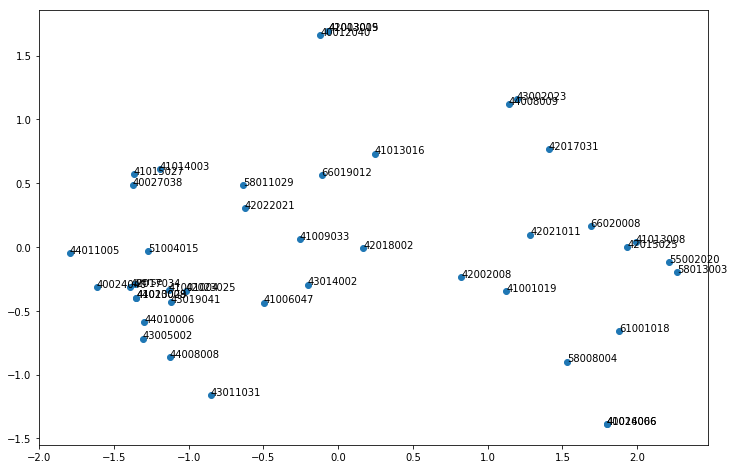

0 eng_in


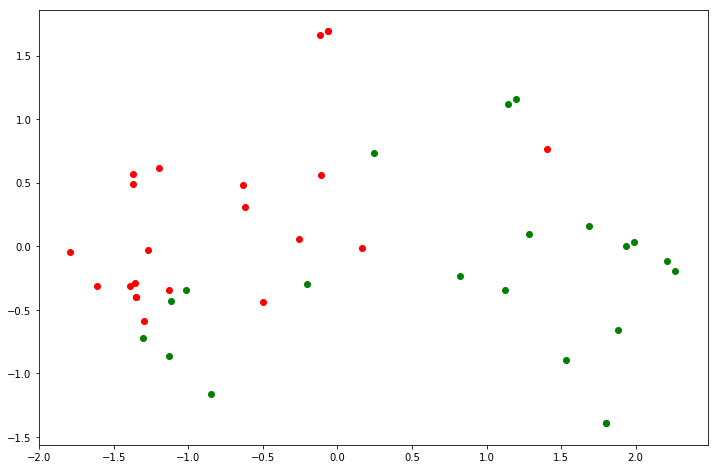

1 eng_on


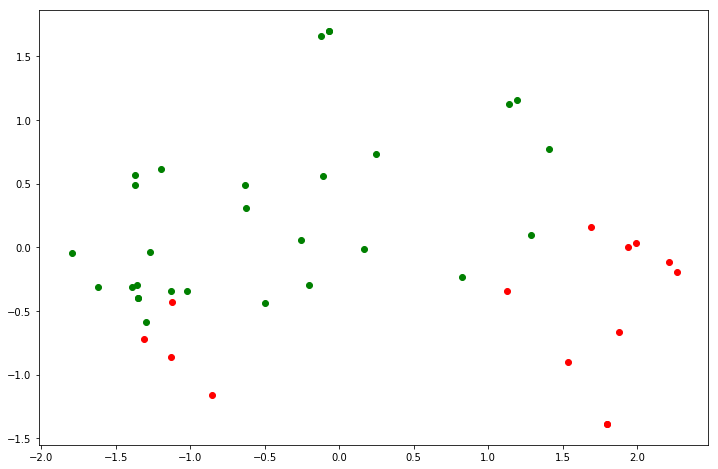

2 eng_at


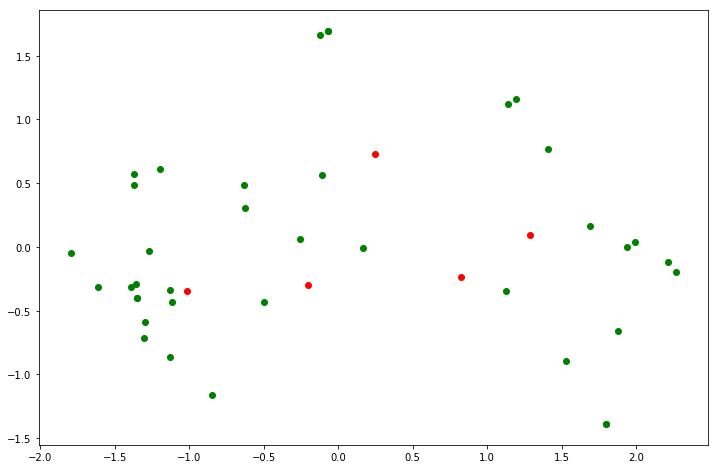

3 eng_by


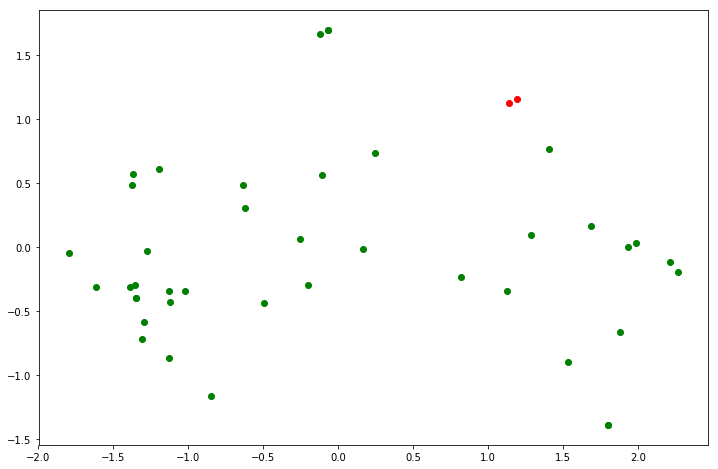

4 cym_yn


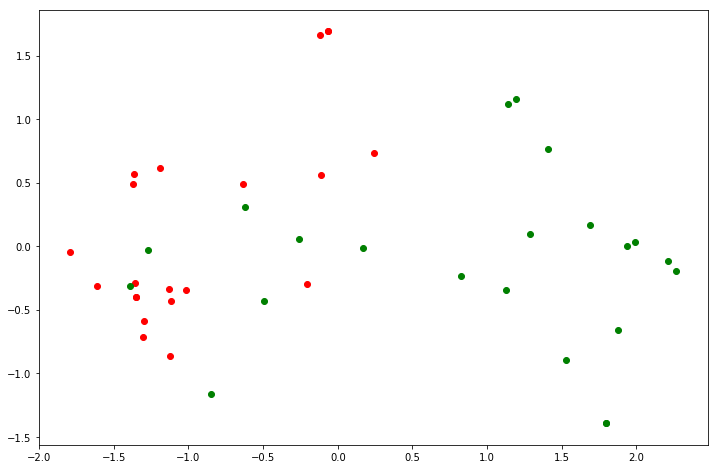

5 cym_ar


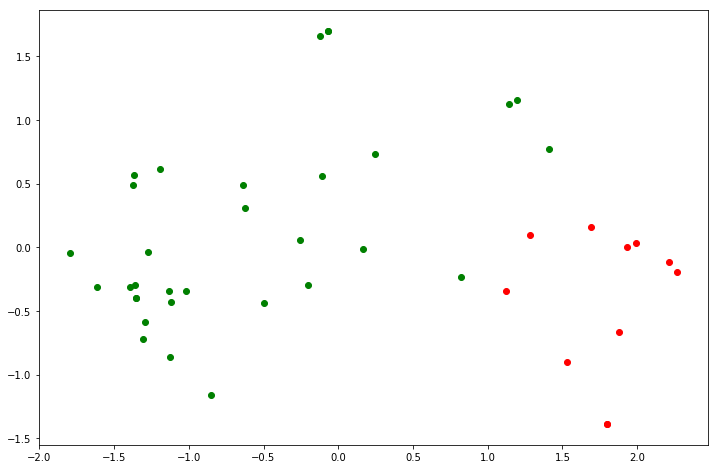

6 cym_NULL


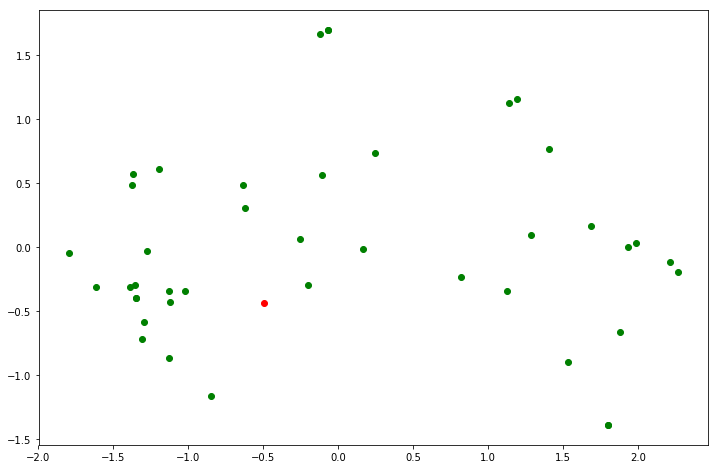

7 cym_mewn


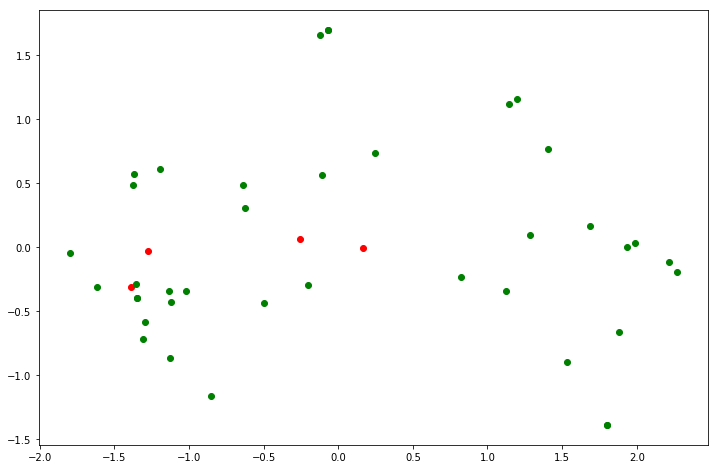

8 cym_wrth


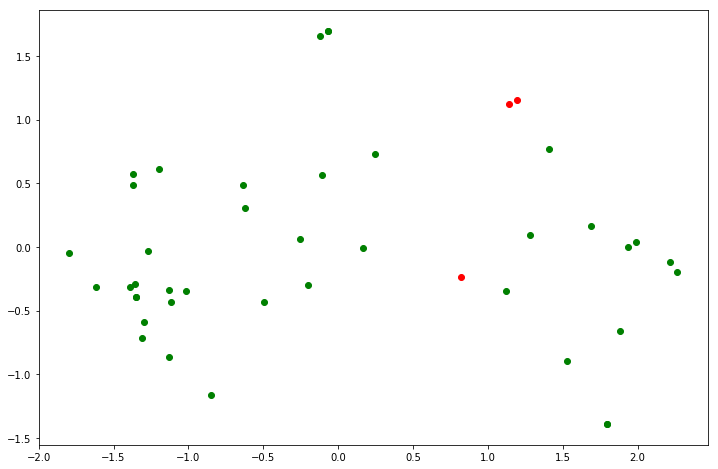

9 deu_in


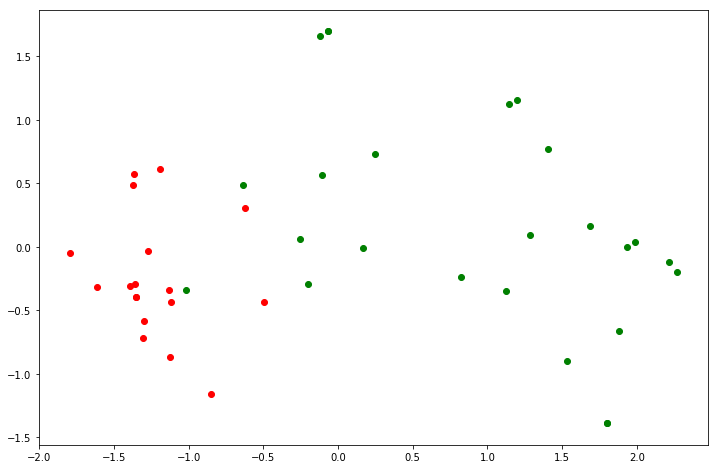

10 deu_auf


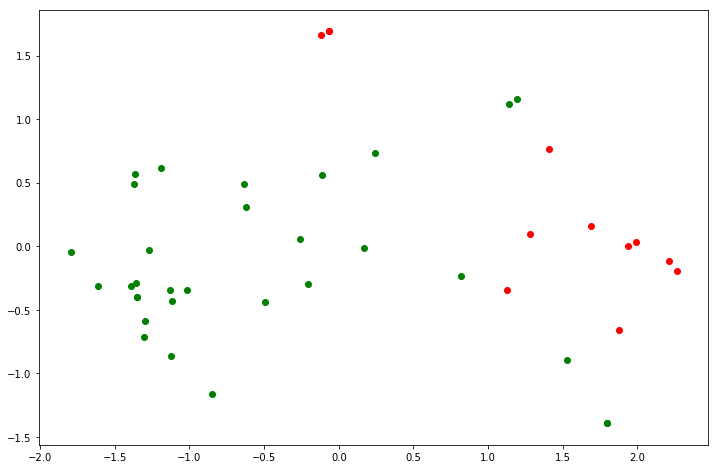

11 deu_zur


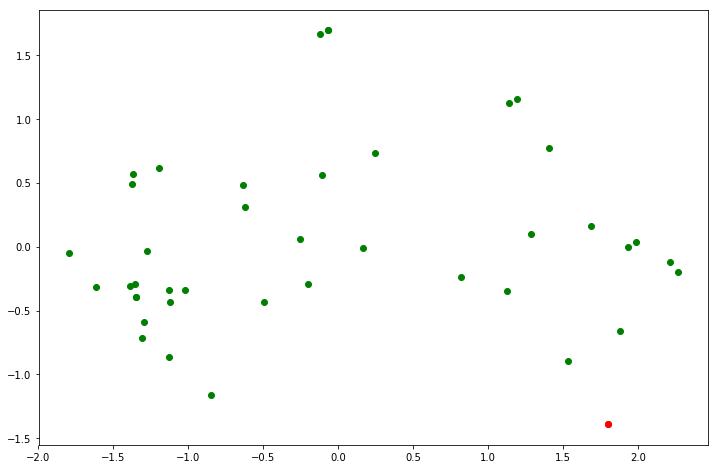

12 deu_vor


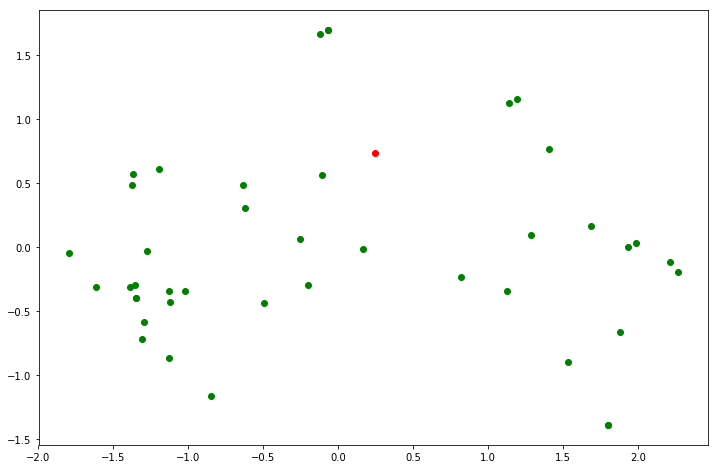

13 deu_an


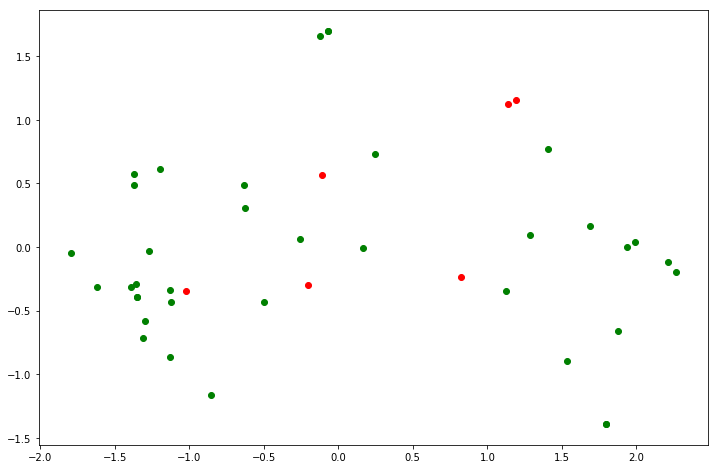

14 fin_-ssa


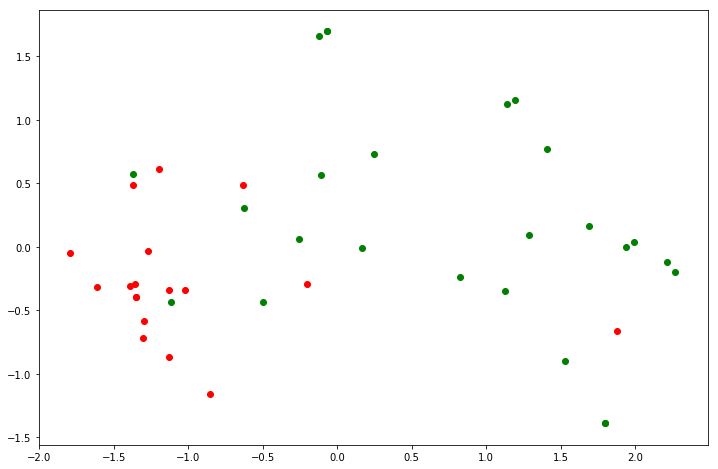

15 fin_-lla


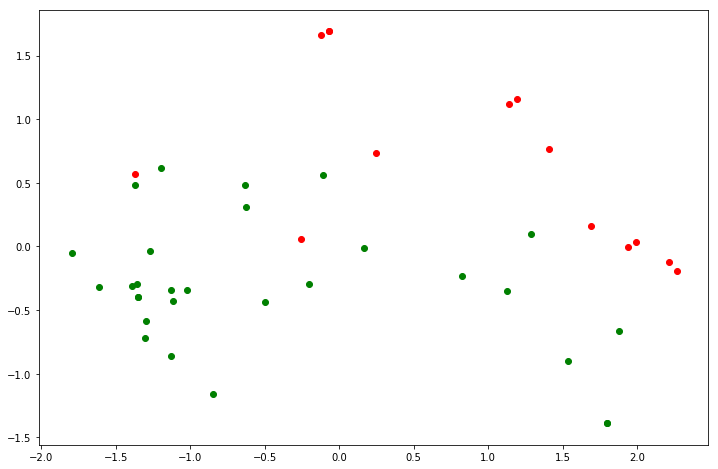

16 fin_-lle


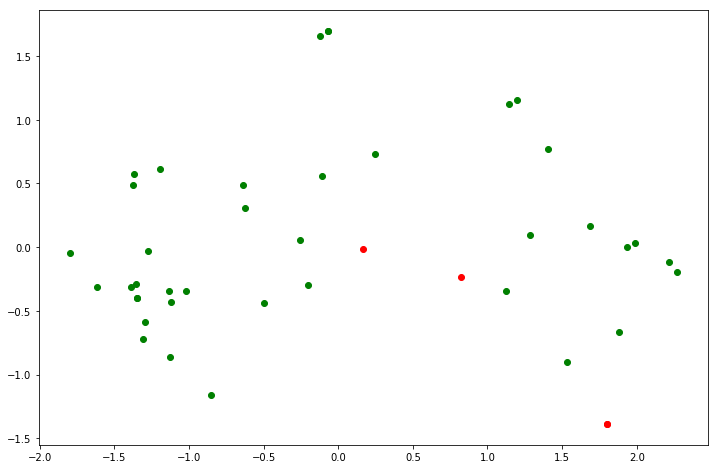

17 hat_nan


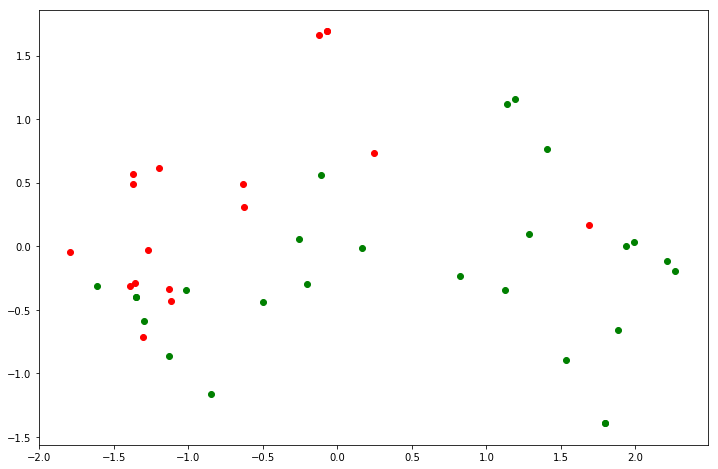

18 hat_sou


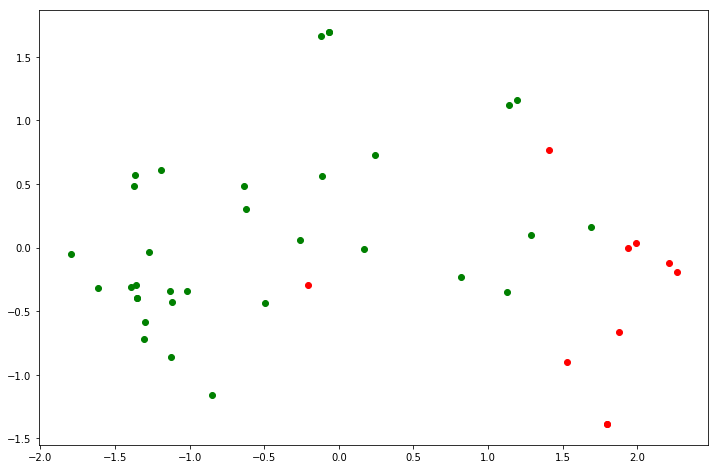

19 hat_NULL


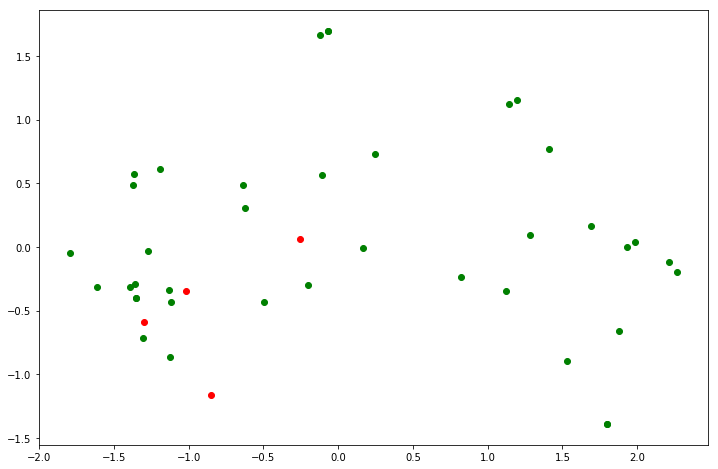

20 hat_bò


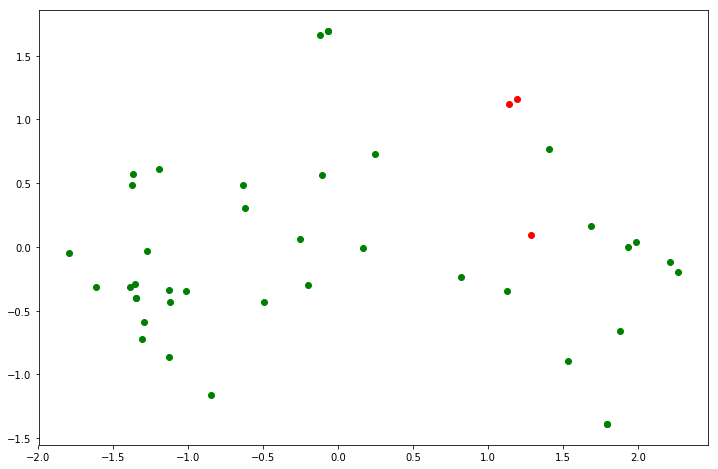

21 hat_la


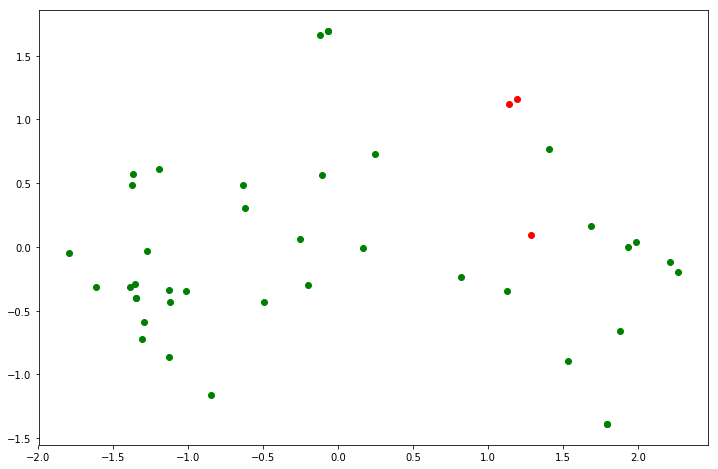

22 hau_cikin


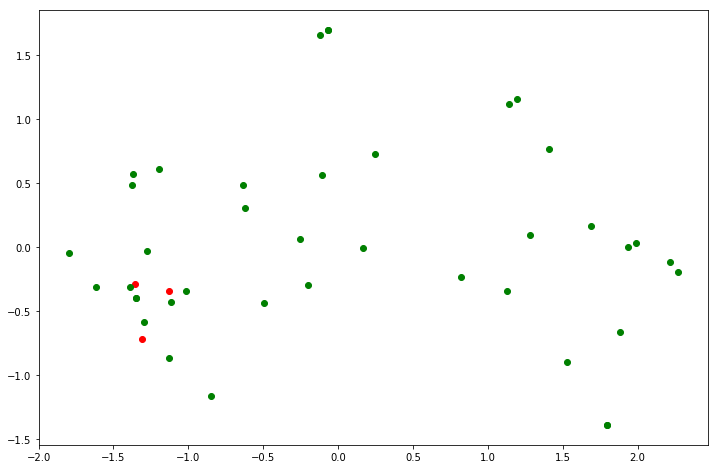

23 hau_a


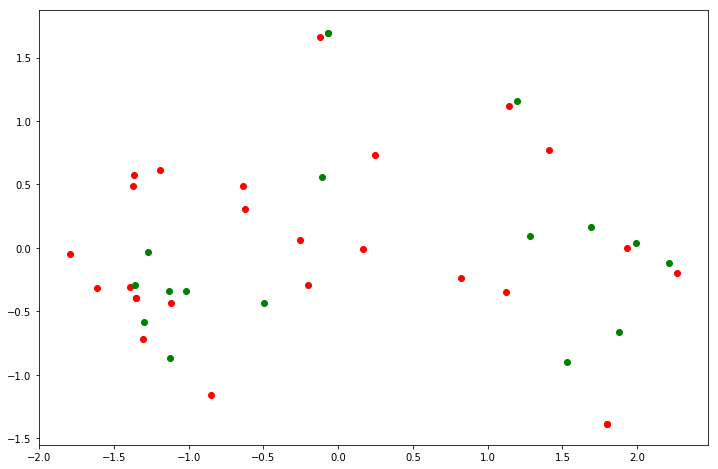

24 hau_kan


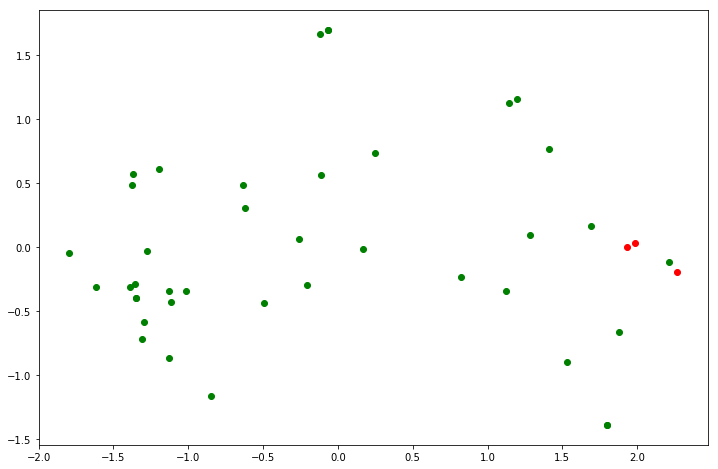

25 hau_ciki


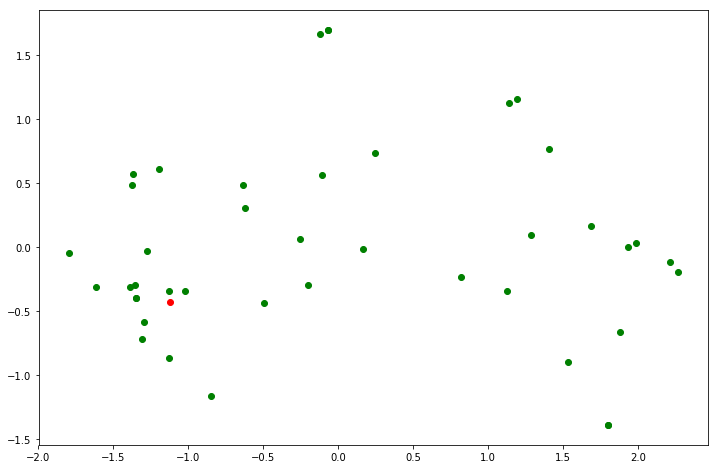

26 hau_NULL


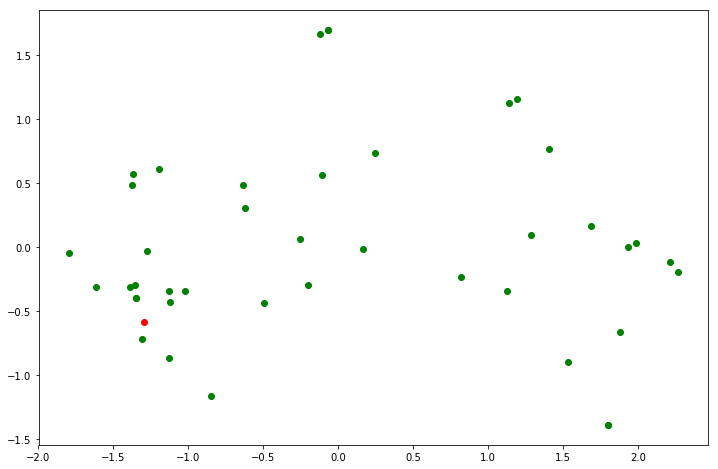

27 hin_mẽ


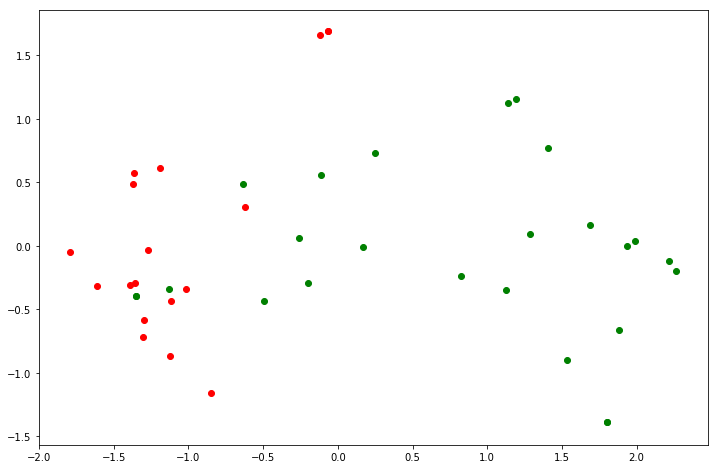

28 hin_par


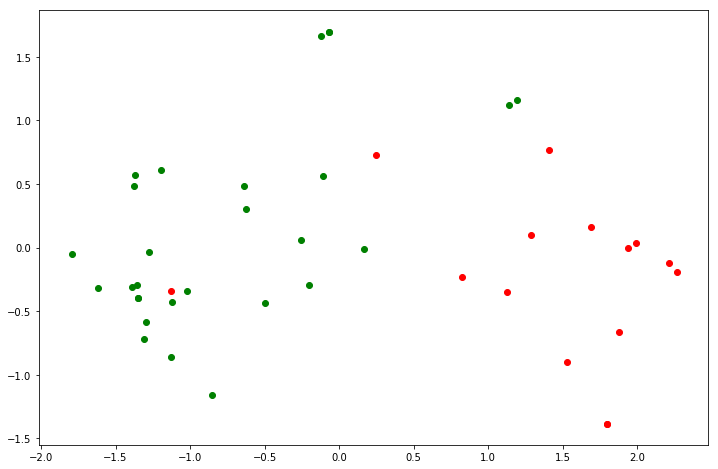

29 hin_NULL


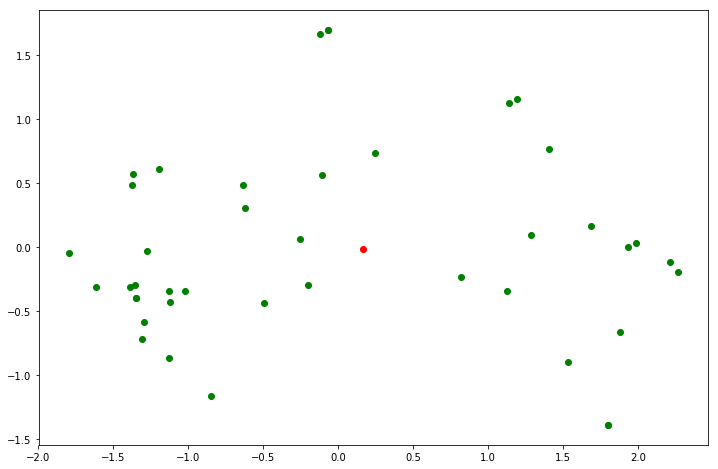

30 hin_cpx


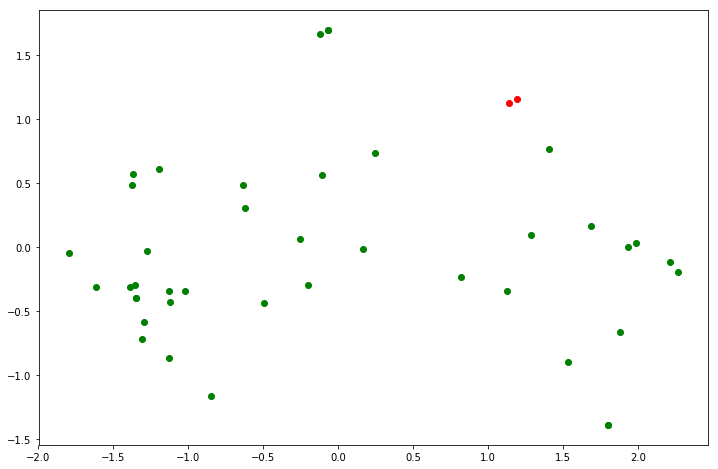

31 hin_oar


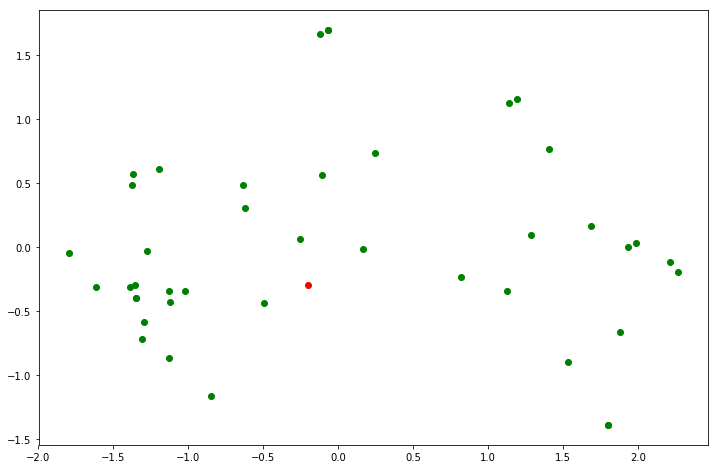

32 jav_ing


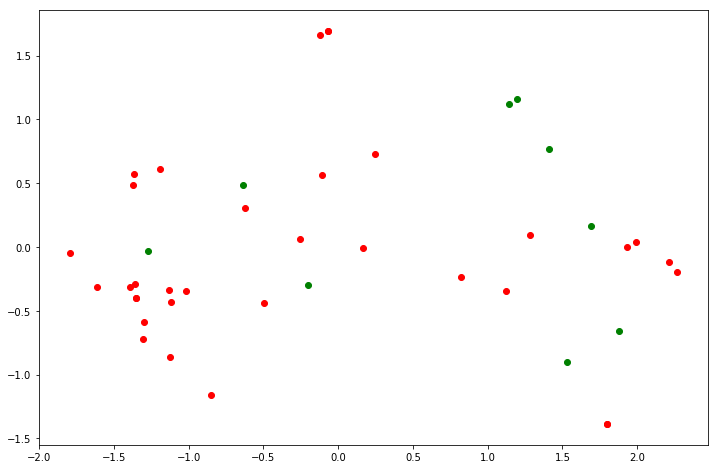

33 jav_cpx


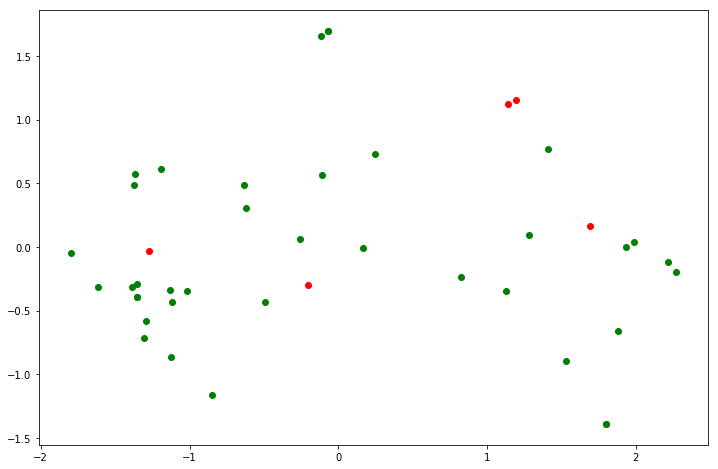

34 pol_w


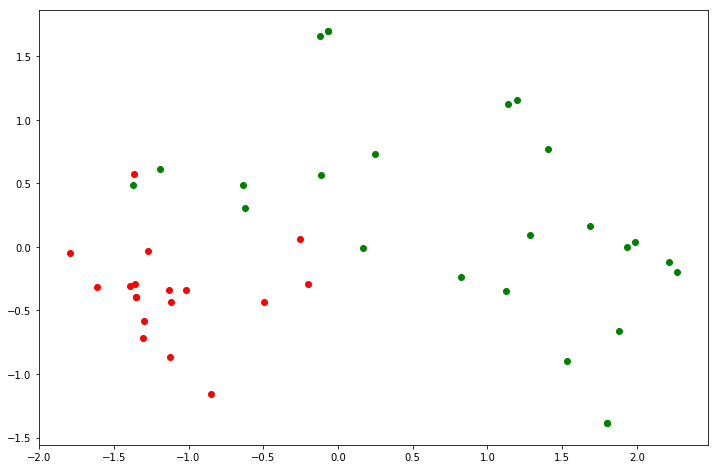

35 pol_na


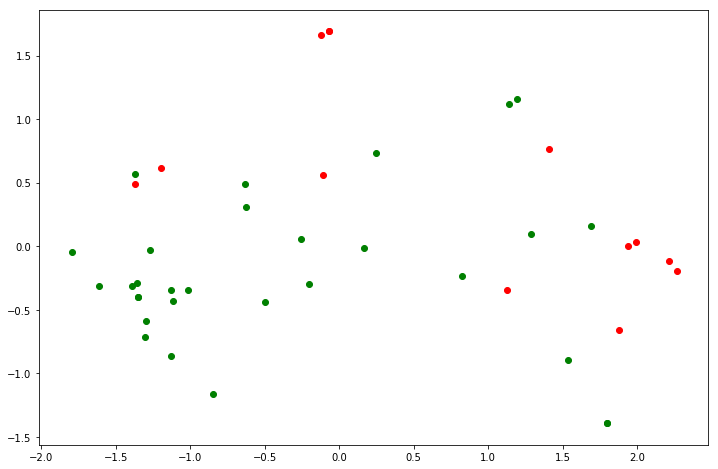

36 pol_z


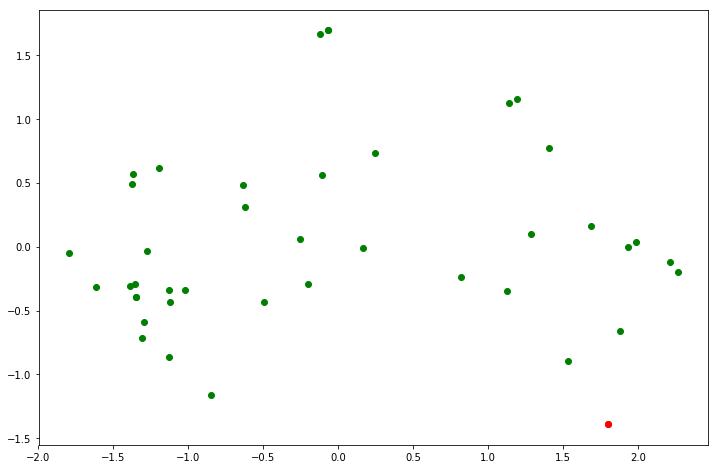

37 pol_u


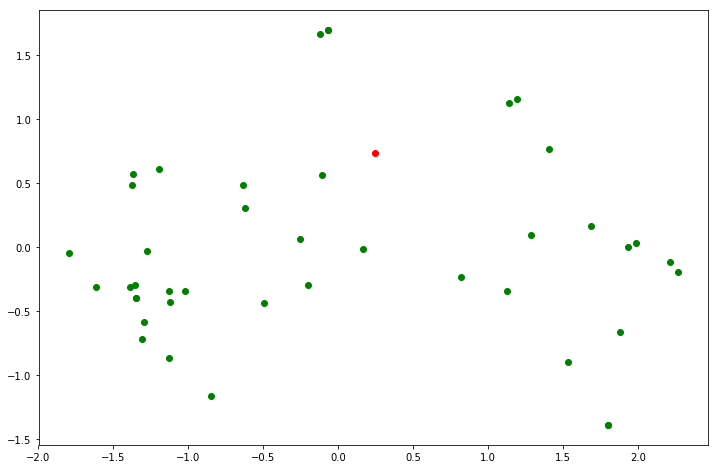

38 pol_przy


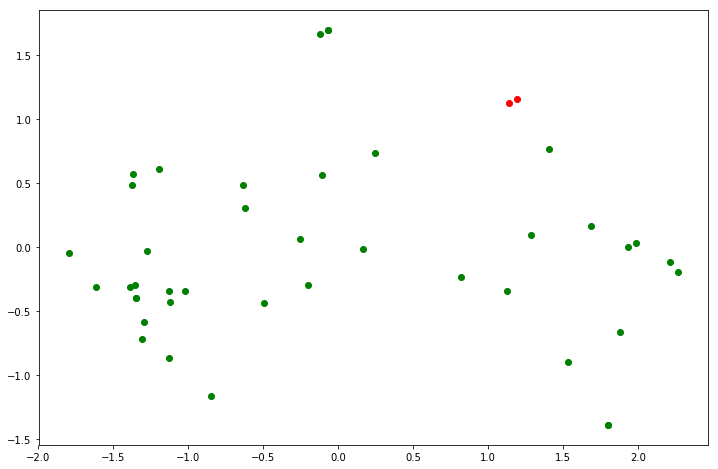

39 tur_-inda


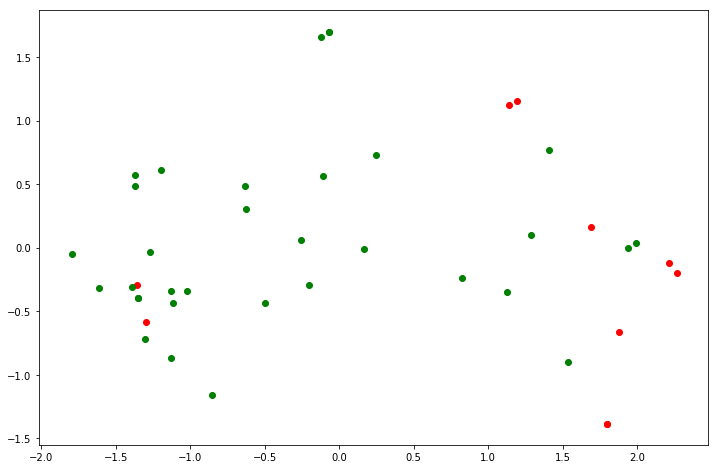

40 tur_-da


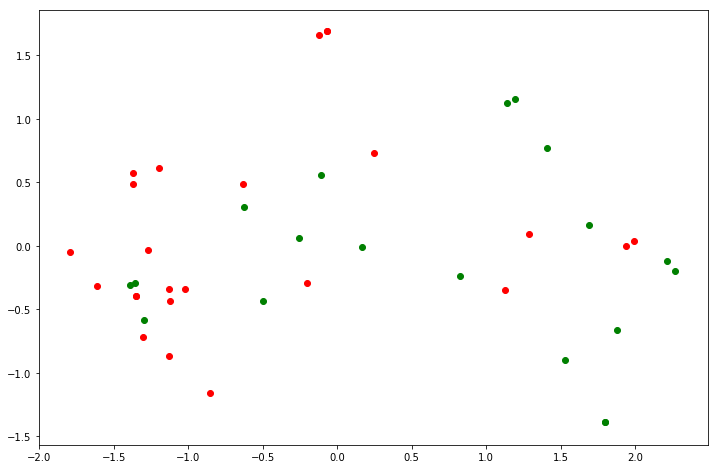

41 yor_ninu


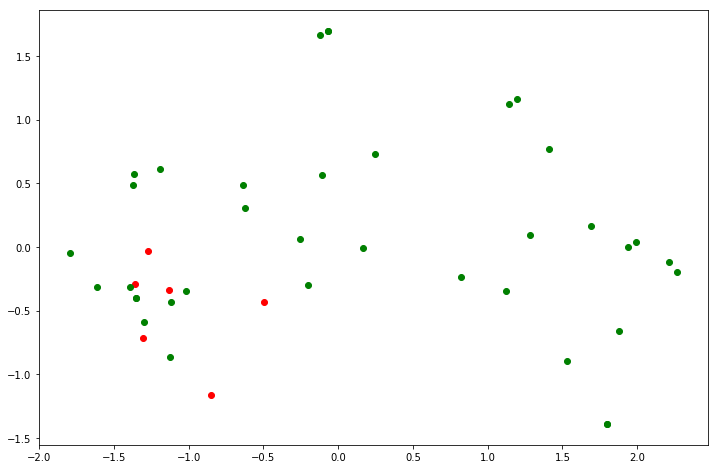

42 yor_li


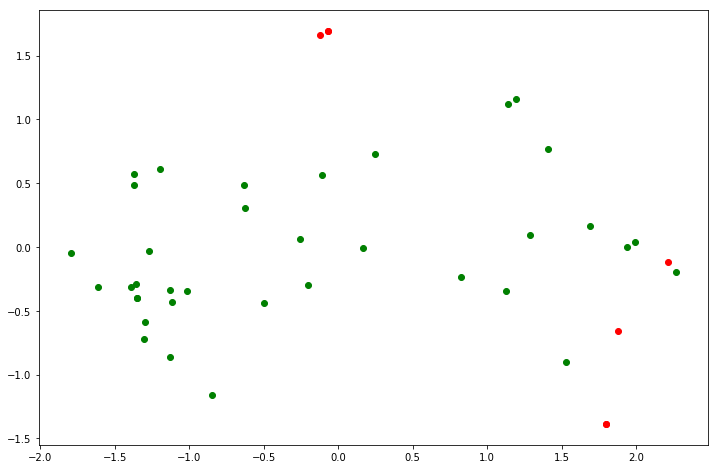

43 yor_ni


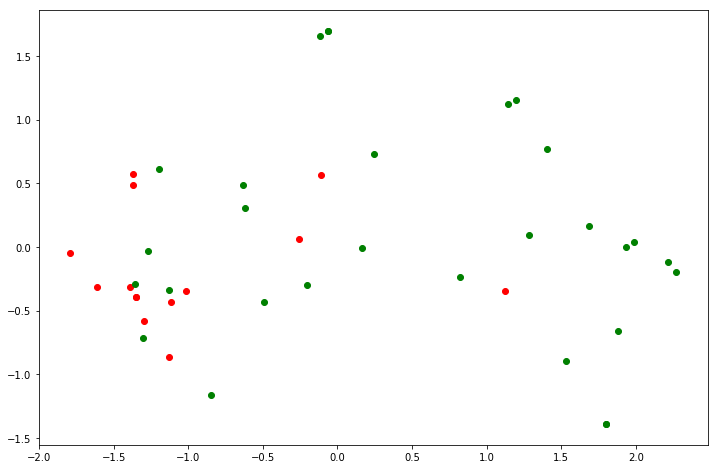

44 yor_lori


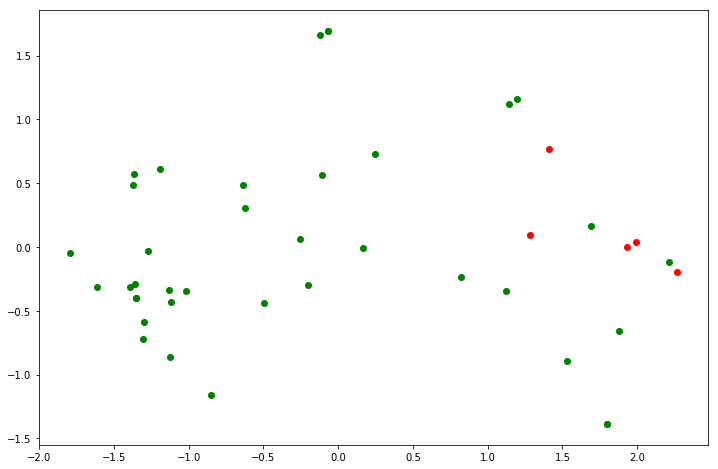

45 yor_lẹhin


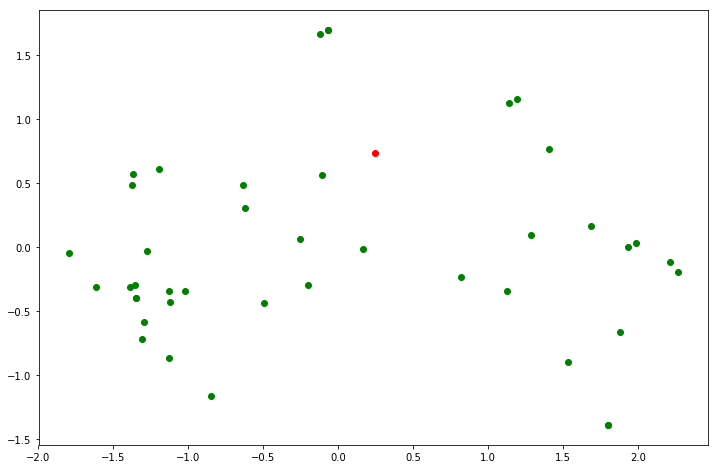

46 yor_cpx


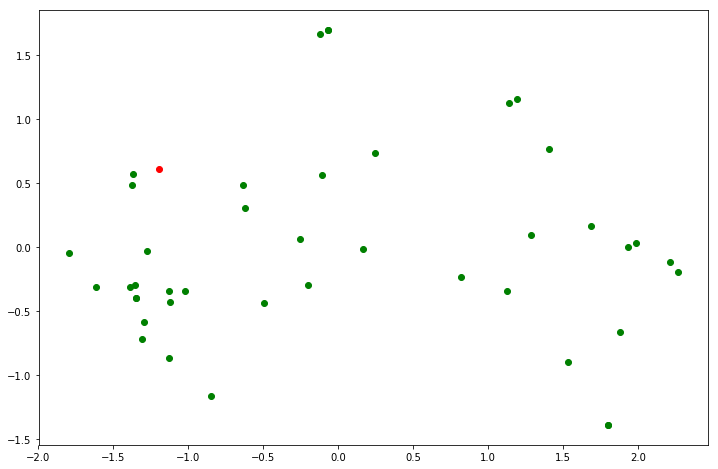

47 yor_sinu


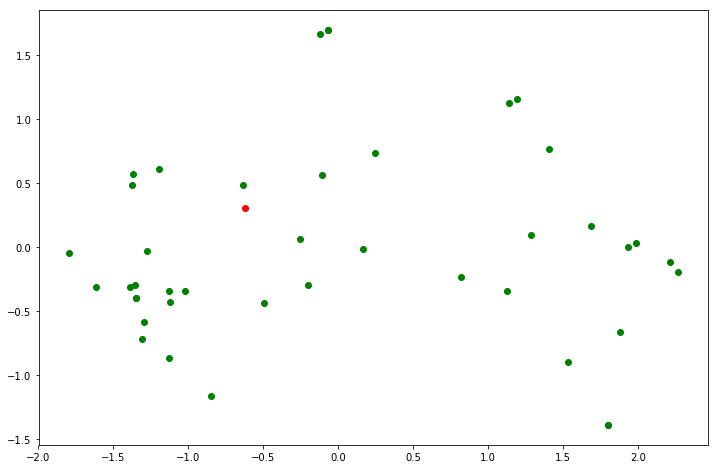

48 yor_leti


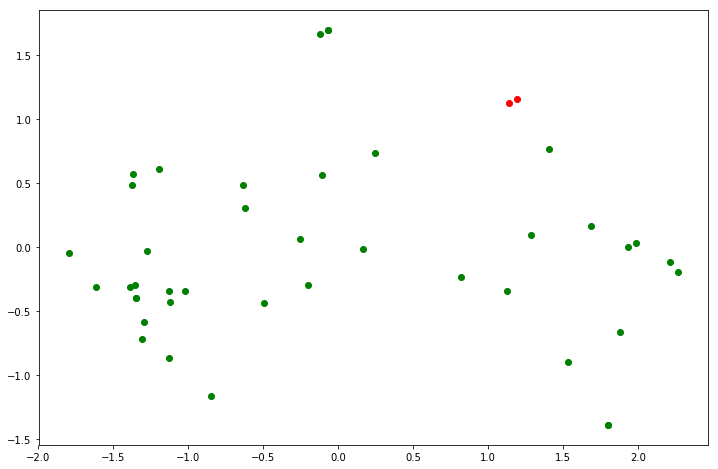

49 yor_


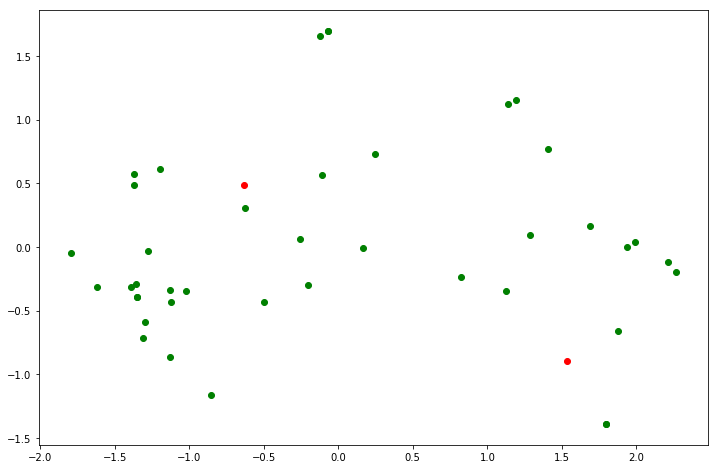

In [31]:
from matplotlib import pyplot as plt
dimension_x = 0
dimension_y = 2
plt.rcParams["figure.figsize"] = (12,8)
plt.scatter(x=coordinates[:,dimension_x],y=coordinates[:,dimension_y])
for i,row in enumerate(dense_coding_table[1:]):
    plt.text(x=coordinates[i,dimension_x],y=coordinates[i,dimension_y],s=dense_coding_table[i][0])
plt.show()
for i,term in enumerate(header):
    print(i,term)
    present = [j for j,row in enumerate(sparse_coding_table) if row[i] == 1]
    absent  = [j for j,row in enumerate(sparse_coding_table) if row[i] == 0]
    plt.scatter(x=coordinates[present,dimension_x], y=coordinates[present,dimension_y], c = 'r')
    plt.scatter(x=coordinates[absent,dimension_x], y=coordinates[absent,dimension_y], c = 'g')
    plt.show()
    plt.close()